## API References

https://www.mccdaq.com/PDFs/Manuals/UL-Linux/python/api.html

# Imports

In [114]:
from uldaq import get_daq_device_inventory, DaqDevice, InterfaceType, AiInputMode, Range, AOutFlag, AInFlag

## Initialize device

In [98]:
try:
    devices = get_daq_device_inventory(InterfaceType.USB)

    # Create a DaqDevice Object and connect to the device
    daq_device = DaqDevice(devices[0])
    daq_device.connect()
    
    # Get AoDevice and AoInfo objects for the analog input subsystem
    ao_device = daq_device.get_ao_device()
    ao_info = ao_device.get_info()
    
    # Get AiDevice
    ai_device = daq_device.get_ai_device()

except ULException as e:
    print('\n', e)

## Set +9 V reference voltage in AOut1 (Pin 8 - Connector 30 S) 

In [107]:
ao_device.a_out(channel=1, analog_range=Range.BIP10VOLTS, flags=AOutFlag.DEFAULT, data=9)

## Set temperature AOut1 (0.15 V in Pin 4 - Connector 30 S)

In [247]:
ao_device.a_out(channel=0, analog_range=Range.BIP10VOLTS, flags=AOutFlag.DEFAULT, data=-0.01)

In [313]:
setpoint_out = ai_device.a_in(channel=4, input_mode=AiInputMode.DIFFERENTIAL, analog_range=Range.BIP10VOLTS, flags=AInFlag.DEFAULT)
print(f'Set Point Output: {setpoint_out*100:.2f}')

Set Point Output: 16.67


In [310]:
bath_temp = ai_device.a_in(channel=5, input_mode=AiInputMode.DIFFERENTIAL, analog_range=Range.BIP10VOLTS, flags=AInFlag.DEFAULT)
print(f'Bath Temp: {bath_temp*100:.2f}')

Bath Temp: 16.59


In [335]:
setpoints = []

for i in range(1000):
    setpoint_out = ai_device.a_in(channel=5, input_mode=AiInputMode.DIFFERENTIAL, analog_range=Range.BIP10VOLTS, flags=AInFlag.DEFAULT)
    setpoints.append(setpoint_out*100)

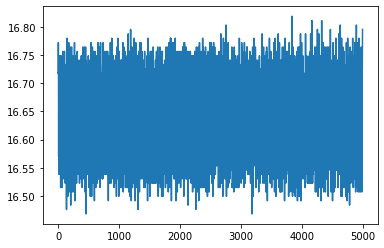

In [340]:
import matplotlib.pyplot as plt

plt.plot(setpoints)

In [337]:
setpoints

[16.717814329240355,
 16.717814329240355,
 16.73344031769375,
 16.772505288827233,
 16.749066306147142,
 16.749066306147142,
 16.686562352333567,
 16.63187139274669,
 16.569367438933114,
 16.647497381200083,
 16.639684386973386,
 16.57718043315981,
 16.6006194158399,
 16.561554444706417,
 16.55374145047972,
 16.538115462026326,
 16.55374145047972,
 16.545928456253023,
 16.561554444706417,
 16.584993427386507,
 16.592806421613204,
 16.647497381200083,
 16.70218834078696,
 16.670936363880173,
 16.70218834078696,
 16.67874935810687,
 16.694375346560264,
 16.670936363880173,
 16.749066306147142,
 16.749066306147142,
 16.72562732346705,
 16.73344031769375,
 16.710001335013658,
 16.624058398519992,
 16.670936363880173,
 16.6006194158399,
 16.57718043315981,
 16.584993427386507,
 16.584993427386507,
 16.63187139274669,
 16.522489473572932,
 16.514676479346235,
 16.569367438933114,
 16.538115462026326,
 16.545928456253023,
 16.63187139274669,
 16.686562352333567,
 16.670936363880173,
 16.69437

In [334]:
ai_cfg = ai_device.get_config()

In [305]:
ai_cfg.set_reject_freq_type(2)

ULException: ULError.CONFIG_NOT_SUPPORTED: Configuration not supported

In [ ]:
import time

try:
    # Get a list of available DAQ devices
    devices = get_daq_device_inventory(InterfaceType.USB)
    # Create a DaqDevice Object and connect to the device
    daq_device = DaqDevice(devices[0])
    daq_device.connect()
    # Get AiDevice and AiInfo objects for the analog input subsystem
    ai_device = daq_device.get_ai_device()
    ai_info = ai_device.get_info()

    # Read and display voltage values for all analog input channels
    for i in range(5):
        time.sleep(5)
        print('\n')
        for channel in range(ai_info.get_num_chans()):
            data = ai_device.a_in(channel, AiInputMode.SINGLE_ENDED,
                                  Range.BIP10VOLTS, AInFlag.DEFAULT)
            print('Channel', channel, 'Data:', data)

    daq_device.disconnect()
    daq_device.release()

except ULException as e:
    print('\n', e)  # Display any error messages